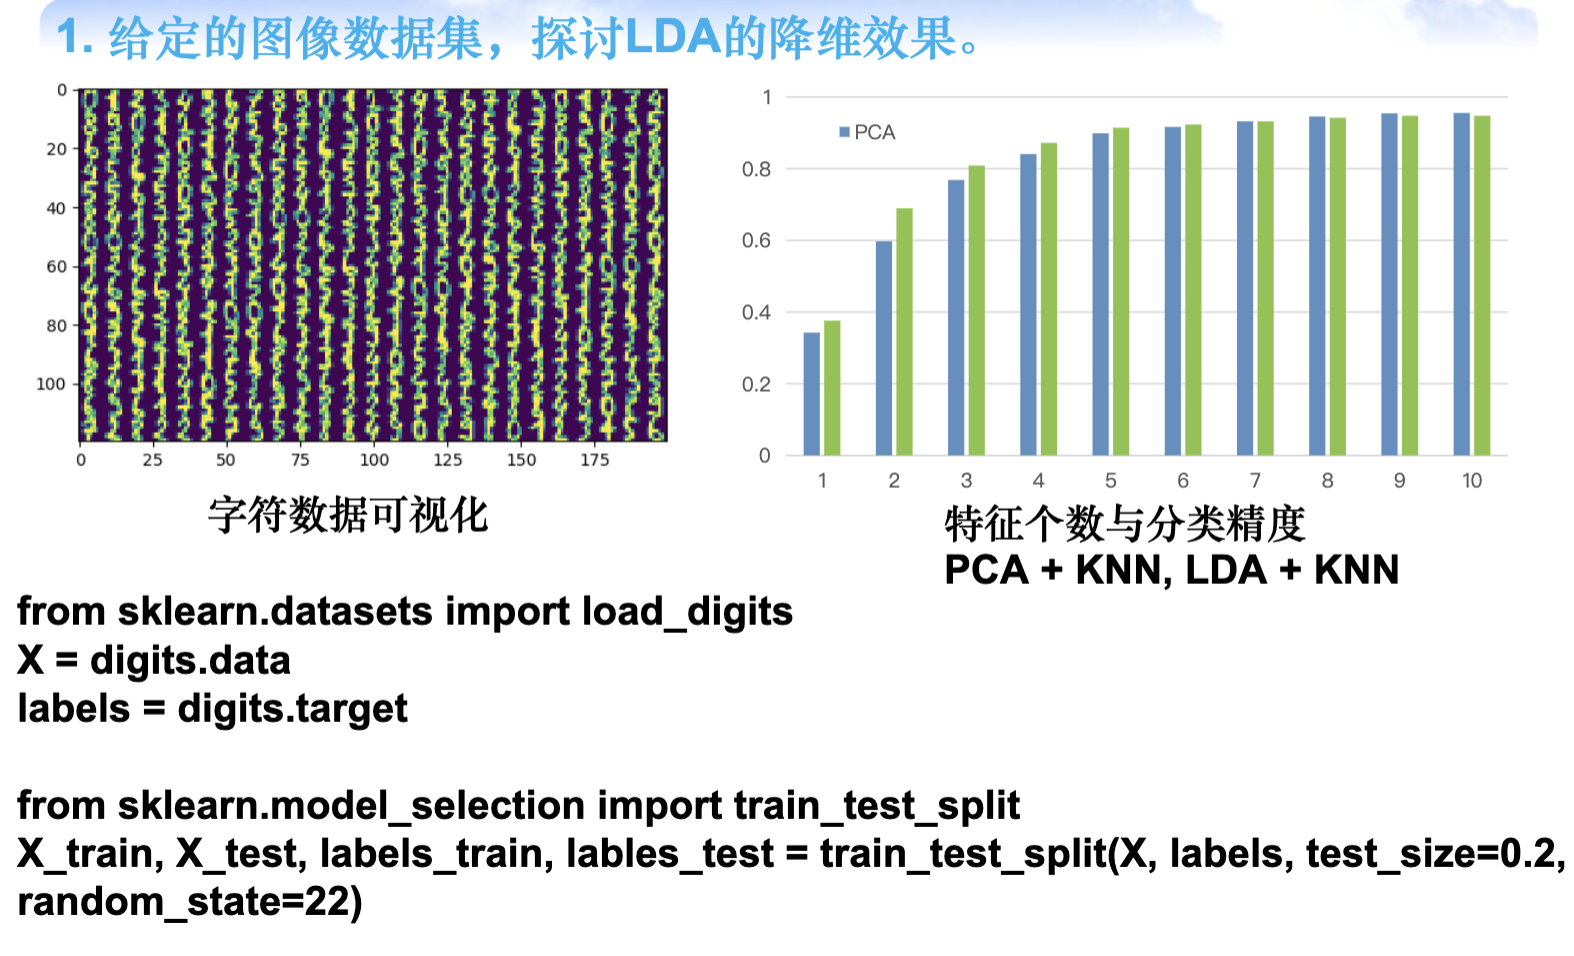

导入数据并检查

In [58]:
from sklearn.datasets import load_digits

digits = load_digits()

X = digits.data
labels = digits.target

# print("X shape:", X.shape)
# print("labels shape:", labels.shape)

# print("第一笔数据：")
# print(X[0])

# print("第一笔标签：", labels[0])


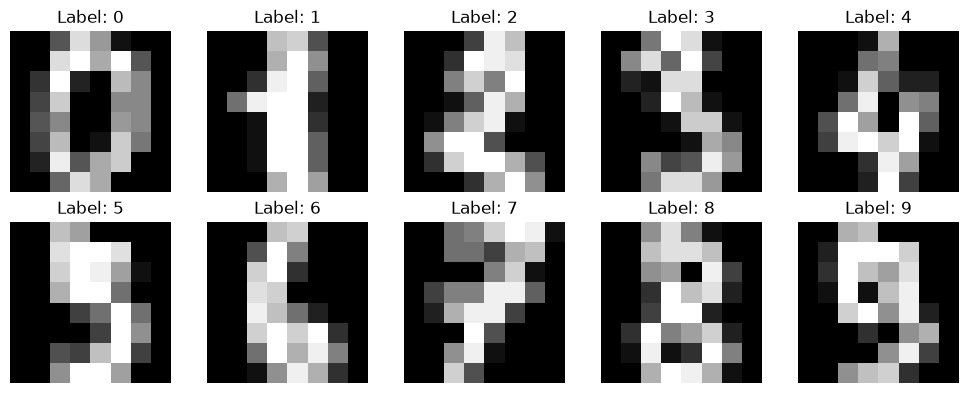

In [59]:
import matplotlib.pyplot as plt

# 检查第一张照片
# plt.imshow(digits.images[0], cmap="gray")
# plt.title("Label: " + str(labels[0]))
# plt.show()


# 一次输出10张照片
fig, axes = plt.subplots(2, 5, figsize=(10, 4))

for i, ax in enumerate(axes.ravel()):
    ax.imshow(digits.images[i], cmap="gray")
    ax.set_title("Label: " + str(labels[i]))
    ax.axis("off")

plt.tight_layout()
plt.show()

数据切成训练集（0.8）和测试集（0.2）

In [60]:
from sklearn.model_selection import train_test_split

X_train, X_test, labels_train, labels_test = train_test_split(
    X,
    labels,
    test_size=0.2,
    random_state=22
)

# print("X_train:", X_train.shape)
# print("X_test:", X_test.shape)
# print("labels_train:", labels_train.shape)
# print("labels_test:", labels_test.shape)


# 建立一个基准 KNN
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

knn = KNeighborsClassifier(n_neighbors=3)

knn.fit(X_train, labels_train)

labels_pred = knn.predict(X_test)

acc = accuracy_score(labels_test, labels_pred)

print("原始特征数量:", X_train.shape[1])
print("KNN Accuracy:", acc)

原始特征数量: 64
KNN Accuracy: 0.9944444444444445


PCA 降到 1 维，再用 KNN 分类

In [61]:
from sklearn.decomposition import PCA

pca = PCA(n_components=1)

X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

print("PCA前训练集:", X_train.shape)
print("PCA后训练集:", X_train_pca.shape)
print("PCA后测试集:", X_test_pca.shape)

PCA前训练集: (1437, 64)
PCA后训练集: (1437, 1)
PCA后测试集: (360, 1)


In [62]:
knn_pca = KNeighborsClassifier(n_neighbors=3)

knn_pca.fit(X_train_pca, labels_train)

labels_pred_pca = knn_pca.predict(X_test_pca)

acc_pca = accuracy_score(labels_test, labels_pred_pca)

print("PCA特征个数:", 1)
print("PCA + KNN Accuracy:", acc_pca)

PCA特征个数: 1
PCA + KNN Accuracy: 0.30277777777777776


LDA 降到 1 维 + KNN 分类

In [63]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
lda = LinearDiscriminantAnalysis(n_components=1)

X_train_lda = lda.fit_transform(X_train, labels_train)
X_test_lda = lda.transform(X_test)

print("LDA前训练集:", X_train.shape)
print("LDA后训练集:", X_train_lda.shape)
print("LDA后测试集:", X_test_lda.shape)

LDA前训练集: (1437, 64)
LDA后训练集: (1437, 1)
LDA后测试集: (360, 1)


In [64]:
knn_lda = KNeighborsClassifier(n_neighbors=3)

knn_lda.fit(X_train_lda, labels_train)

labels_pred_lda = knn_lda.predict(X_test_lda)

acc_lda = accuracy_score(labels_test, labels_pred_lda)

print("LDA特征个数:", 1)
print("LDA + KNN Accuracy:", acc_lda)

LDA特征个数: 1
LDA + KNN Accuracy: 0.33611111111111114


PCA：1～10 维。

In [65]:
# 先做 PCA：1～10 维

pca_acc_list = []

for n in range(1, 11):

    pca = PCA(n_components=n)

    X_train_pca = pca.fit_transform(X_train)
    X_test_pca = pca.transform(X_test)

    knn = KNeighborsClassifier(n_neighbors=3)

    knn.fit(X_train_pca, labels_train)

    labels_pred = knn.predict(X_test_pca)

    acc = accuracy_score(labels_test, labels_pred)

    pca_acc_list.append(acc)

    #print("PCA特征个数:", n, "Accuracy:", acc)
    
# 做 LDA：1～9 维    
lda_acc_list = []

for n in range(1, 10):

    lda = LinearDiscriminantAnalysis(n_components=n)

    X_train_lda = lda.fit_transform(X_train, labels_train)
    X_test_lda = lda.transform(X_test)

    knn = KNeighborsClassifier(n_neighbors=3)

    knn.fit(X_train_lda, labels_train)

    labels_pred = knn.predict(X_test_lda)

    acc = accuracy_score(labels_test, labels_pred)

    lda_acc_list.append(acc)

    #print("LDA特征个数:", n, "Accuracy:", acc)


可视化

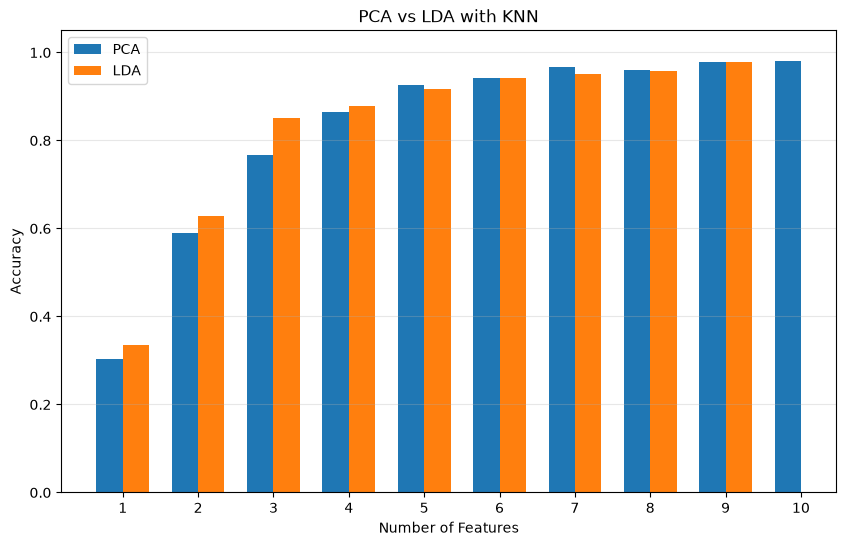

In [66]:
import numpy as np
import matplotlib.pyplot as plt

# 特征个数
pca_features = np.arange(1, 11)
lda_features = np.arange(1, 10)

width = 0.35

plt.figure(figsize=(10, 6))

# PCA：1~10维
plt.bar(
    pca_features - width / 2,
    pca_acc_list,
    width=width,
    label="PCA"
)

# LDA：1~9维
plt.bar(
    lda_features + width / 2,
    lda_acc_list,
    width=width,
    label="LDA"
)

plt.xlabel("Number of Features")
plt.ylabel("Accuracy")
plt.title("PCA vs LDA with KNN")

plt.xticks(range(1, 11))
plt.ylim(0, 1.05)

plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.show()

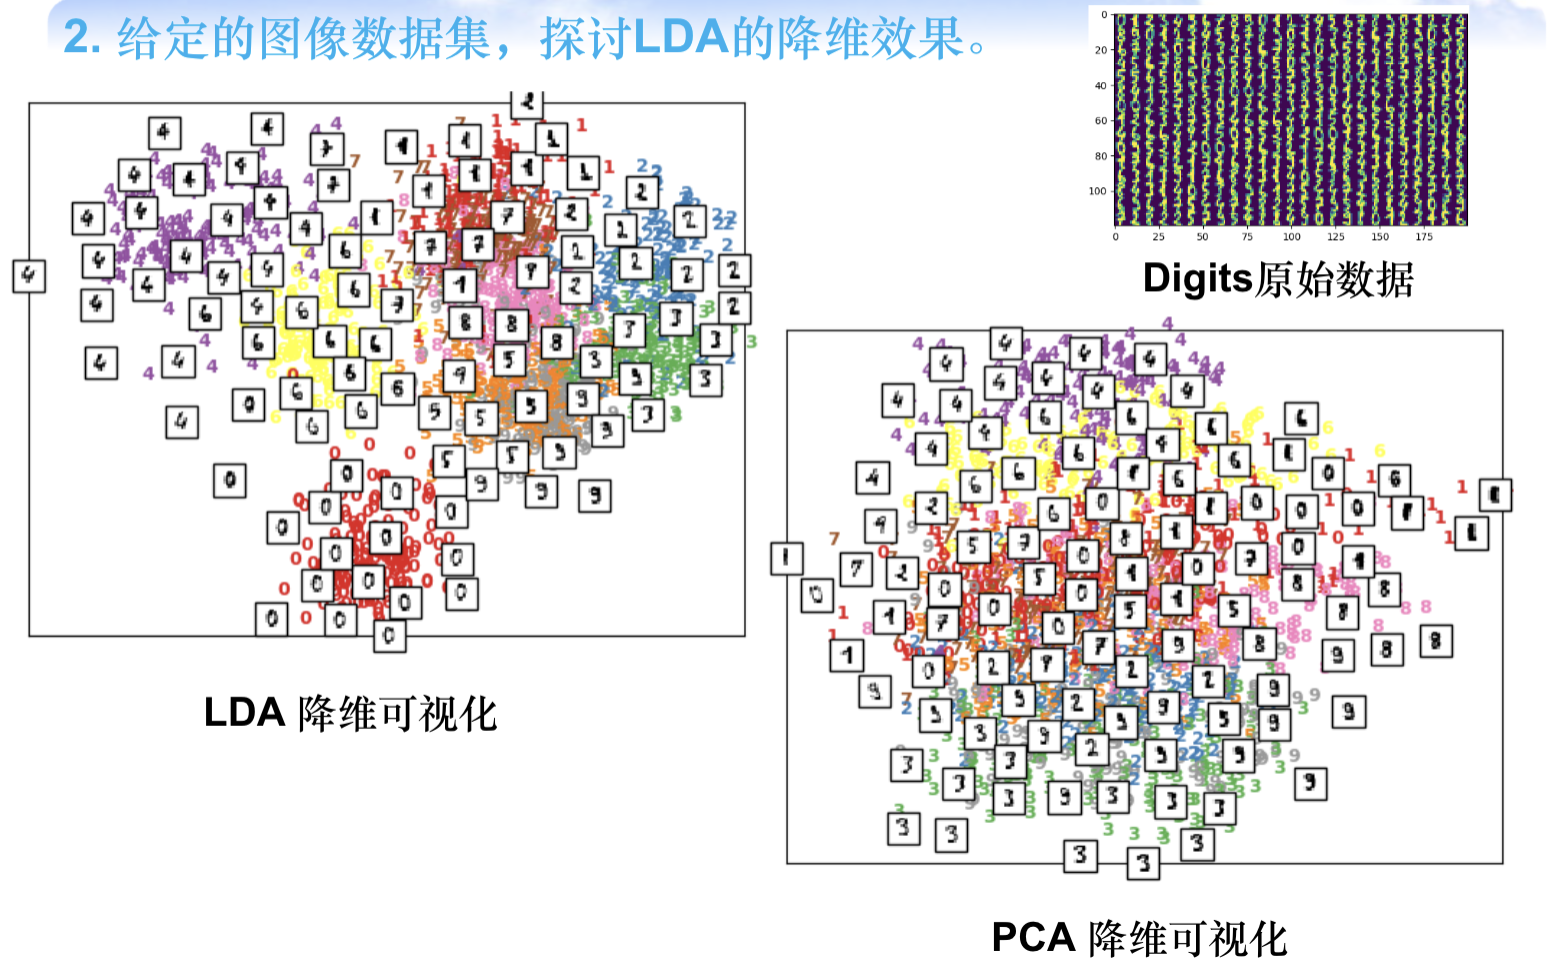

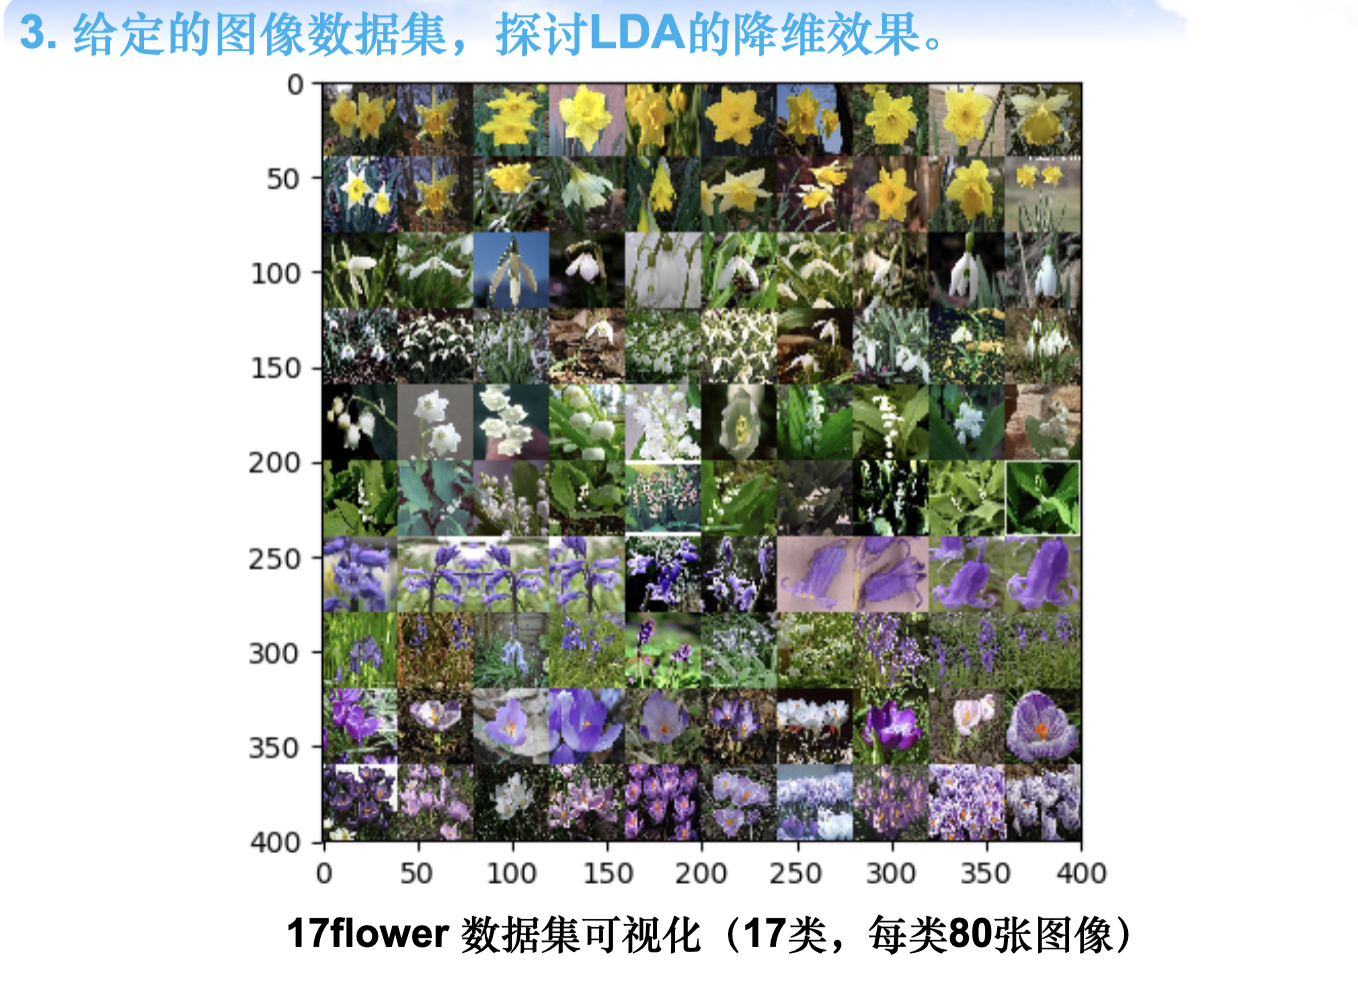